# Gesamtdokument: Face Model Lab

Ziel des Projekts ist ein praktisch nutzbares, selbst trainiertes Modell zur Gesichtserkennung und anschliessenden Video-Anonymisierung. Verglichen wurden YOLOv8m, Faster R-CNN, RetinaNet und FCOS auf den Datensatz WIDER FACE. COCO-pretrained Modelle wurden nur als Baseline aufgenommen, weil sie nicht face-spezifisch trainiert sind.

Bearbeiter sind **Milena Witt** und **Clemens Schierack**. Die Grundlagen, wie Auswahl des Datensatzes und bestimmung der Struktur dieses Notebooks und einem kleinen Vorprojekt mit "Labelled faces in the wild" wurden zusammen erstellt.

Dieses Notebook zeigt die im Projekt durchlaufenen Schritte fortlaufend. Im Githu Repo https://github.com/globalx-prog/face_model_lab sind diese in einzelne Python Skripte unterteilt und das Modelltraining oder das Blurring von Videos kann gezielter und effizienter gesteuert werden.

## Lokale Umsetzung

- Das Notebook nutzt die registrierte Kernel-Umgebung `Python MIM ROCm` mit `torch 2.9.1+rocm6.4`.
- Die Arbeitsstruktur liegt projektlokal in `datasets/`, `annotations/`, `trained_models/`, `kaggle_cache/` und `notebook_runs/`.
- Der vorhandene WIDER FACE Datensatz wurde nach `datasets/wider_face` verschoben; KaggleHub wird nur noch als Fallback verwendet, falls dieser Ordner fehlt.
- Die WIDER FACE Annotationen werden in COCO-JSON umgewandelt und unter `annotations/instances_train.json` sowie `annotations/instances_val.json` gespeichert.
- Das Faster-R-CNN-Training ist als ROCm-Smoke-Test konfiguriert: `BATCH_SIZE = 2`, `EPOCHS = 1`, reduzierte Datenmenge und Speicherung unter `trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_red2000_ep1.pth`.
- Das Trainings-Device ist ROCm-strikt: PyTorch nutzt dafür `torch.device("cuda")`; bei fehlender ROCm-GPU-Sichtbarkeit bricht die Trainingszelle mit einem klaren Hinweis ab.
- Spätere Zellen vergleichen Modellqualität und führen Video-Deinterlacing, Tracking und ovales Face-Blurring aus.

Für den Vergleich wurden 1000 Bilder genommen `BATCH_SIZE = 2`, `EPOCHS = 10`


# Prerequisites

In [1]:
# !pip install kagglehub numpy==1.26.4 opencv-python==4.9.0.80 opencv-contrib-python==4.9.0.80 tifffile==2023.12.9 pycocotools ultralytics insightface facenet-pytorch matplotlib ffmpeg

from pathlib import Path
import os

def find_project_root(start=None):
    start_path = Path(start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "datasets" / "wider_face").exists():
            return candidate
        if (candidate / "face_model_lab").exists() and (candidate / "datasets").exists():
            return candidate
    return start_path


PROJECT_ROOT = find_project_root()
DATASETS_DIR = PROJECT_ROOT / "datasets"
KAGGLE_CACHE_DIR = PROJECT_ROOT / "kaggle_cache"
ANNOTATIONS_DIR = PROJECT_ROOT / "annotations"
MODEL_DIR = PROJECT_ROOT / "trained_models"
NOTEBOOK_RUNS_DIR = PROJECT_ROOT / "notebook_runs"
MPLCONFIG_DIR = PROJECT_ROOT / "matplotlib_cache"

for directory in [DATASETS_DIR, KAGGLE_CACHE_DIR, ANNOTATIONS_DIR, MODEL_DIR, NOTEBOOK_RUNS_DIR, MPLCONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ["KAGGLEHUB_CACHE"] = str(KAGGLE_CACHE_DIR)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)

local_dataset_path = DATASETS_DIR / "wider_face"
required_dataset_paths = [
    local_dataset_path / "WIDER_train" / "WIDER_train" / "images",
    local_dataset_path / "WIDER_val" / "WIDER_val" / "images",
    local_dataset_path / "wider_face_split" / "wider_face_split" / "wider_face_train_bbx_gt.txt",
    local_dataset_path / "wider_face_split" / "wider_face_split" / "wider_face_val_bbx_gt.txt",
]

if all(item.exists() for item in required_dataset_paths):
    path = str(local_dataset_path.resolve())
else:
    import kagglehub
    downloaded_dataset_path = Path(kagglehub.dataset_download("mksaad/wider-face-a-face-detection-benchmark"))
    if not local_dataset_path.exists():
        local_dataset_path.symlink_to(downloaded_dataset_path, target_is_directory=True)
        path = str(local_dataset_path.resolve())
    else:
        path = str(downloaded_dataset_path.resolve())

print("Project root:", PROJECT_ROOT)
print("Path to dataset files:", path)


Project root: /home/clemi/projekte/MIM
Path to dataset files: /home/clemi/projekte/MIM/datasets/wider_face


# Datensatz anschauen (zufälliges Beispiel)

Erfolgreich Annotationen für 12880 Bilder geladen.


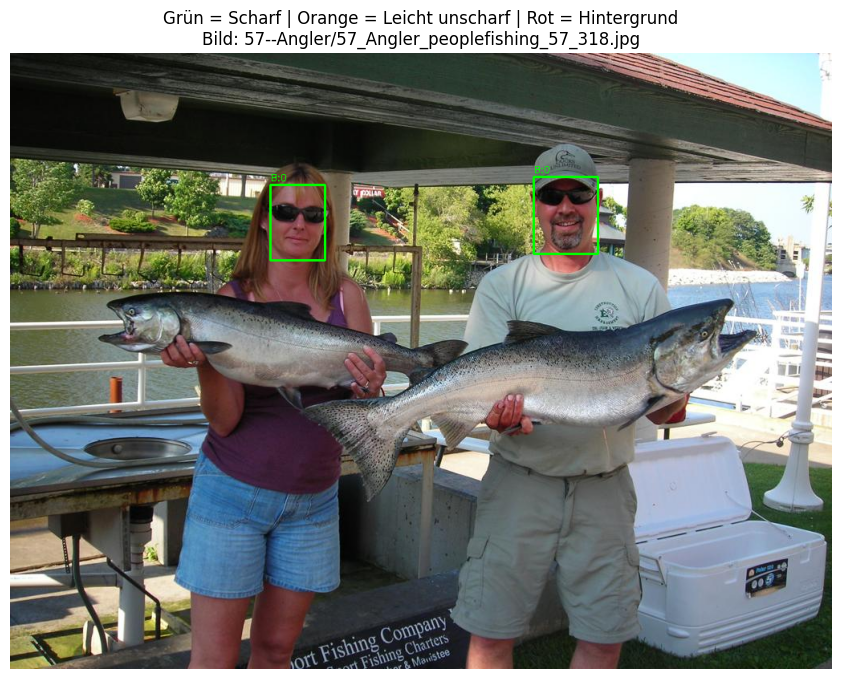

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# 1. Pfade definieren (basierend auf dem vorherigen Download)
base_path = path 
gt_file_path = os.path.join(base_path, "wider_face_split/wider_face_split/wider_face_train_bbx_gt.txt")
images_dir = os.path.join(base_path, "WIDER_train/WIDER_train/images")

# 2. Parser-Funktion für die WIDER FACE Textdatei
def parse_wider_face_gt(file_path):
    dataset_dict = {}
    
    with open(file_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]
        
    cursor = 0
    while cursor < len(lines):
        # Bildpfad auslesen
        img_relative_path = lines[cursor]
        cursor += 1
        
        # Anzahl der Gesichter auslesen
        num_boxes = int(lines[cursor])
        cursor += 1
        
        boxes = []
        # Wenn keine Gesichter existieren, gibt es im Datensatz trotzdem eine Dummy-Zeile
        if num_boxes == 0:
            cursor += 1
            dataset_dict[img_relative_path] = []
            continue
            
        # Alle Boxen für dieses Bild auslesen
        for _ in range(num_boxes):
            parts = lines[cursor].split()
            # Format: x1, y1, width, height
            bbox = [int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])]
            # Der 5. Wert (Index 4) steht für den Blur-Faktor: 0 = scharf, 1 = leicht unscharf, 2 = stark unscharf
            blur = int(parts[4]) 
            
            boxes.append({"bbox": bbox, "blur": blur})
            cursor += 1
            
        dataset_dict[img_relative_path] = boxes
        
    return dataset_dict

# Annotationen laden
annotations = parse_wider_face_gt(gt_file_path)
print(f"Erfolgreich Annotationen für {len(annotations)} Bilder geladen.")

# 3. Anpassung: Wähle ein ZUFÄLLIGES Bild aus dem gesamten Datensatz
# Wir konvertieren die dict_keys in eine Liste, um daraus zufällig zu wählen
all_image_paths = list(annotations.keys())
random_example_img_path = random.choice(all_image_paths)

# 4. Bild laden und Boxen einzeichnen
if random_example_img_path:
    full_image_path = os.path.join(images_dir, random_example_img_path)
    image = cv2.imread(full_image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Boxen durchgehen
    for face in annotations[random_example_img_path]:
        x, y, w, h = face["bbox"]
        blur_level = face["blur"]
        
        # Farbcodierung basierend auf der Unschärfe im Datensatz:
        # Grün = Scharf (Vordergrund), Orange = Leicht unscharf, Rot = Stark unscharf (Hintergrund)
        if blur_level == 0:
            color = (0, 255, 0)  # Grün
        elif blur_level == 1:
            color = (255, 165, 0) # Orange
        else:
            color = (255, 0, 0)  # Rot
            
        # Box zeichnen
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
        # Blur-Level als Text über die Box schreiben
        cv2.putText(image, f"B:{blur_level}", (x, max(0, y - 5)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    # Anzeigen
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Grün = Scharf | Orange = Leicht unscharf | Rot = Hintergrund\nBild: {random_example_img_path}")
    plt.show()
else:
    print("Kein passendes Beispielbild mit mehreren Gesichtern gefunden.")

# Eigenes Modell trainieren mit Faster R-CNN

**Clemens Schierack** fokussiert sich auf Aufgaben zur Modellauswahl und Training dieser. Es stehen neben den zwei hier im Smoke Test dargestellten Architekuren noch Weitere zur Auswahl wobei die Suche nach besseren/schnelleren Modellen weiter läuft. Das Training der Modelle geschah primär auf einer lokalen Radeon GPU mit untzerschiedlichen Datensatzgrößen und zuerst niedriger Qualität. 

YOLO, R-CNN und RetinaNet sind bekannte Verfahren zur **Objekterkennung** in Bildern, also Modelle, die nicht nur sagen *was* zu sehen ist, sondern auch *wo* es ist, meist per Bounding Box.

**YOLO**
YOLO steht für “You Only Look Once”. Das Modell betrachtet das Bild in einem einzigen Durchlauf und sagt direkt Objektklassen und Bounding Boxes voraus. Es ist besonders schnell und deshalb beliebt für Echtzeit-Anwendungen wie Videoanalyse, Robotik oder Kamerasysteme.

Kurz gesagt: **sehr schnell, oft etwas gröber, gut für Echtzeit**.

**R-CNN**
R-CNN steht für “Region-based Convolutional Neural Network”. Die Grundidee ist: Erst werden mögliche Bildregionen vorgeschlagen, in denen Objekte sein könnten, dann werden diese Regionen klassifiziert. Varianten wie **Fast R-CNN** und **Faster R-CNN** machten das Verfahren deutlich effizienter.

Kurz gesagt: **genauer, aber meist langsamer als YOLO**.

**RetinaNet**
RetinaNet ist ein sogenannter **One-Stage Detector** wie YOLO, arbeitet also ohne separaten Region-Proposal-Schritt. Sein wichtiger Beitrag ist die **Focal Loss**: Damit lernt das Modell besser aus schwierigen Beispielen und wird nicht von den vielen einfachen Hintergrundbereichen dominiert.

Kurz gesagt: **guter Kompromiss aus Geschwindigkeit und Genauigkeit**.

Ganz grob:

| Modell | Typ | Stärke |
|---|---|---|
| YOLO | One-stage detector | sehr schnell |
| R-CNN / Faster R-CNN | Two-stage detector | hohe Genauigkeit |
| RetinaNet | One-stage detector | ausgewogen, robust bei Klassenungleichgewicht |

In [ ]:
import os
import cv2
import json
import torch
import torchvision
import numpy as np
from pathlib import Path
from pycocotools.coco import COCO
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from tqdm.auto import tqdm

# ==========================================
# 1. KONFIGURATION & PFADE
# ==========================================
# Projektlokale Pfade: Datensatz, COCO-Annotationen und neue Modellgewichte
if "PROJECT_ROOT" not in globals():
    def find_project_root(start=None):
        start_path = Path(start or Path.cwd()).resolve()
        for candidate in [start_path, *start_path.parents]:
            if (candidate / "datasets" / "wider_face").exists():
                return candidate
            if (candidate / "face_model_lab").exists() and (candidate / "datasets").exists():
                return candidate
        return start_path

    PROJECT_ROOT = find_project_root()

ANNOTATIONS_DIR = PROJECT_ROOT / "annotations"
MODEL_DIR = PROJECT_ROOT / "trained_models"
ANNOTATIONS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR = os.path.join(path, "WIDER_train/WIDER_train/images")
TXT_ANNOTATION_PATH = os.path.join(path, "wider_face_split/wider_face_split/wider_face_train_bbx_gt.txt")
ANN_FILE = str(ANNOTATIONS_DIR / "instances_train.json")
NUM_CLASSES = 2        # 1 (Hintergrund) + 1 (Gesicht)
EPOCHS = 1             # Smoke-Test: genau eine Epoche
BATCH_SIZE = 2         # Klein halten, aber ROCm-GPU nutzen
MODEL_TYPE = "fasterrcnn_resnet50_fpn_rocm"
SAVE_PATH = str(MODEL_DIR / f"{MODEL_TYPE}_bs{BATCH_SIZE}_ep{EPOCHS}.pth")
REDUCTION_FACTOR = 10  # Reduziert den Datensatz für schnellere Tests (z.B. 10 = nur jedes 10. Bild)
REQUIRE_ROCM_GPU = True

def convert_wider_to_coco(txt_path, json_output_path):
    print(f"Lese WIDER FACE Annotationen aus: {txt_path} ...")
    
    coco_data = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "face"}]
    }
    
    if not Path(txt_path).exists():
        raise FileNotFoundError(f"Die Datei {txt_path} wurde nicht gefunden. Bitte Pfad prüfen!")

    with open(txt_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    line_idx = 0
    ann_id = 1
    img_id = 1
    
    while line_idx < len(lines):
        file_path = lines[line_idx].strip()
        line_idx += 1
        if line_idx >= len(lines):
            break
            
        num_boxes = int(lines[line_idx].strip())
        line_idx += 1
        
        # Bild zur Liste hinzufügen
        # (WIDER FACE liefert im TXT keine Bildgrößen, Faster R-CNN verzeiht hier Platzhalter)
        coco_data["images"].append({
            "id": img_id,
            "file_name": file_path,
            "width": 0,  
            "height": 0
        })
        
        if num_boxes == 0:
            # WIDER FACE hat manchmal eine Null-Zeile bei Bildern ohne Gesichter
            # Wir prüfen, ob die nächste Zeile auf .jpg endet. Wenn nicht, überspringen wir sie.
            if line_idx < len(lines) and not lines[line_idx].strip().endswith('.jpg'):
                line_idx += 1
            img_id += 1
            continue

        for _ in range(num_boxes):
            if line_idx >= len(lines): break
            
            parts = lines[line_idx].strip().split()
            line_idx += 1
            
            if len(parts) < 4: continue
            
            x, y, w, h = map(float, parts[:4])
            
            # Annotation hinzufügen
            coco_data["annotations"].append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": 1,
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0
            })
            ann_id += 1
            
        img_id += 1

    # Speichern der JSON-Datei
    with open(json_output_path, "w", encoding="utf-8") as f:
        json.dump(coco_data, f, ensure_ascii=False)
        
    print(f"✅ Konvertierung erfolgreich!")
    print(f"Gespeichert unter: {json_output_path}")
    print(f"Bilder registriert: {len(coco_data['images'])}")
    print(f"Gesichter (Annotations) gefunden: {len(coco_data['annotations'])}")

if __name__ == "__main__":
    convert_wider_to_coco(TXT_ANNOTATION_PATH, ANN_FILE)

# ==========================================
# 2. DATASET & DATALOADER
# ==========================================
class CocoFaceDataset(Dataset):
    def __init__(self, images_dir, ann_file):
        self.images_dir = Path(images_dir)
        self.coco = COCO(str(ann_file))
        self.image_ids = list(self.coco.imgs.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(image_id)[0]
        
        img_path = self.images_dir / img_info["file_name"]
        image_bgr = cv2.imread(str(img_path))
        if image_bgr is None:
            raise FileNotFoundError(f"Bild nicht gefunden: {img_path}")
        
        image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        boxes, labels, areas, iscrowd = [], [], [], []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            # Degenerierte Boxen filtern (verhindert Abstürze)
            if w <= 0 or h <= 0: continue
            x2, y2 = x + w, y + h
            if x2 <= x or y2 <= y: continue

            boxes.append([x, y, x2, y2])
            labels.append(int(ann["category_id"]))
            areas.append(float(ann.get("area", w * h)))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        # Normalisierung
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "area": areas,
            "iscrowd": iscrowd
        }
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

# ==========================================
# 3. MODELL DEFINITION
# ==========================================
def build_faster_rcnn(num_classes):
    # Lade vortrainiertes ResNet50-Modell
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    # Ersetze den Klassifikator-Kopf an unsere Klassenanzahl (Hintergrund + Gesicht)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# ==========================================
# 4. TRAINING & SPEICHERN (Hauptskript)
# ==========================================

def get_rocm_training_device(require_gpu=True):
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        backend = "ROCm" if getattr(torch.version, "hip", None) else "CUDA"
        print(f"Nutze Device: cuda ({backend} GPU: {gpu_name})")
        return torch.device("cuda")

    message = (
        "Keine ROCm-GPU in PyTorch sichtbar. Prüfe /dev/kfd, /dev/dri, "
        "ROCm-Treiber und die Mitgliedschaft in der video/render-Gruppe."
    )
    if require_gpu:
        raise RuntimeError(message)

    print(f"{message} Fallback auf CPU.")
    return torch.device("cpu")

if __name__ == "__main__":
    device = get_rocm_training_device(REQUIRE_ROCM_GPU)

    # Daten laden
    print("Lade COCO Annotationen...")
    full_dataset = CocoFaceDataset(IMAGES_DIR, ANN_FILE)
    
    # Datensatz reduzieren (optional, für schnellere Durchläufe)
    if REDUCTION_FACTOR > 1:
        reduced_indices = list(range(0, len(full_dataset), REDUCTION_FACTOR))
        train_dataset = torch.utils.data.Subset(full_dataset, reduced_indices)
        print(f"Datensatz reduziert: {len(full_dataset)} -> {len(train_dataset)} Bilder.")
    else:
        train_dataset = full_dataset

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

    # Modell, Optimizer und Scheduler initialisieren
    print("Initialisiere Faster R-CNN...")
    model = build_faster_rcnn(NUM_CLASSES)
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    
    # todo: adjust
    optimizer = torch.optim.SGD(params, lr=0.0001, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    # Trainings-Schleife
    print(f"Start Training auf {device}...")
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")
        
        for images, targets in pbar:
            # Ganz normaler Tensor-Transfer auf die CPU (keine Datentyp-Hacks nötig)
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            #TODO show accuracy 
            #L, acc = model.evaluate(images, targets)


            epoch_loss += losses.item()
            pbar.set_postfix({"loss": f"{losses.item():.4f}"})
            
        lr_scheduler.step()
        print(f"Abgeschlossen: Epoch {epoch + 1}/{EPOCHS} | Durchschnitts-Loss: {epoch_loss/len(train_loader):.4f}")

    # Modell speichern
    Path(SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), SAVE_PATH)
    print(f"✅ Training beendet. Modell erfolgreich gespeichert unter: {SAVE_PATH}")
    print(f"   Namensschema: {MODEL_TYPE}_bs{BATCH_SIZE}_ep{EPOCHS}.pth")

Lese WIDER FACE Annotationen aus: /home/clemi/projekte/MIM/datasets/wider_face/wider_face_split/wider_face_split/wider_face_train_bbx_gt.txt ...
✅ Konvertierung erfolgreich!
Gespeichert unter: /home/clemi/projekte/MIM/annotations/instances_train.json
Bilder registriert: 12880
Gesichter (Annotations) gefunden: 159424
Nutze Device: cuda (ROCm GPU: AMD Radeon PRO W7800 48GB)
Lade COCO Annotationen...
loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
Datensatz reduziert: 12880 -> 1288 Bilder.
Initialisiere Faster R-CNN...
Start Training auf cuda...


Epoch 1/1:   0%|          | 0/644 [00:00<?, ?it/s]

# Alternative Modellgenerierung: YOLOv8-Finetuning

Diese Zelle stellt ein alternatives Verfahren bereit: WIDER FACE wird in das YOLO-Label-Format konvertiert und ein YOLOv8-Face-Modell wird feintrainiert. YOLO ist für Video-Inferenz meist die bessere praktische Wahl und nutzt VRAM oft besser, weil Batch-Verarbeitung und Bildgrößensteuerung (`imgsz`) direkter funktionieren als bei Faster R-CNN.


In [ ]:
import shutil
import cv2
from pathlib import Path
from tqdm.auto import tqdm
from ultralytics import YOLO
import torch

# Alternative: YOLOv8-Finetuning mit denselben Smoke-Test-Settings wie Faster R-CNN
YOLO_EPOCHS = EPOCHS if "EPOCHS" in globals() else 1
YOLO_BATCH_SIZE = BATCH_SIZE if "BATCH_SIZE" in globals() else 2
YOLO_IMAGE_SIZE = 1024
YOLO_REDUCTION_FACTOR = REDUCTION_FACTOR if "REDUCTION_FACTOR" in globals() else 1000
YOLO_MODEL_TYPE = "yolov8m_widerface_rocm"
YOLO_RUN_NAME = f"{YOLO_MODEL_TYPE}_bs{YOLO_BATCH_SIZE}_ep{YOLO_EPOCHS}"
YOLO_DATASET_DIR = PROJECT_ROOT / "datasets" / "wider_face_yolo_smoke"
YOLO_MODEL_OUTPUT = MODEL_DIR / f"{YOLO_RUN_NAME}.pt"


def format_vram_status(device):
    if device.type != "cuda" or not torch.cuda.is_available():
        return "CPU / keine CUDA-ROCm-GPU sichtbar"
    allocated = torch.cuda.memory_allocated(device) / 1024**3
    reserved = torch.cuda.memory_reserved(device) / 1024**3
    total = torch.cuda.get_device_properties(device).total_memory / 1024**3
    return f"allocated={allocated:.2f} GB, reserved={reserved:.2f} GB, total={total:.2f} GB"


def parse_wider_annotations_for_yolo(txt_path):
    items = []
    lines = Path(txt_path).read_text(encoding="utf-8", errors="replace").splitlines()
    cursor = 0
    while cursor < len(lines):
        rel_path = lines[cursor].strip()
        cursor += 1
        if not rel_path or cursor >= len(lines):
            continue
        num_faces = int(lines[cursor].strip())
        cursor += 1
        boxes = []
        for _ in range(num_faces):
            parts = lines[cursor].strip().split()
            cursor += 1
            if len(parts) >= 4:
                x, y, w, h = map(float, parts[:4])
                if w > 0 and h > 0:
                    boxes.append((x, y, w, h))
        if boxes:
            items.append((rel_path, boxes))
    return items


def prepare_yolo_split(split_name, image_root, wider_txt, reduction_factor=1):
    image_out = YOLO_DATASET_DIR / "images" / split_name
    label_out = YOLO_DATASET_DIR / "labels" / split_name
    for output_dir in [image_out, label_out]:
        if output_dir.exists():
            shutil.rmtree(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

    items = parse_wider_annotations_for_yolo(wider_txt)
    if reduction_factor > 1:
        items = items[::reduction_factor]

    for rel_path, boxes in tqdm(items, desc=f"YOLO Labels {split_name}"):
        src_img = Path(image_root) / rel_path
        dst_img = image_out / rel_path
        dst_label = label_out / Path(rel_path).with_suffix(".txt")
        dst_img.parent.mkdir(parents=True, exist_ok=True)
        dst_label.parent.mkdir(parents=True, exist_ok=True)

        img = cv2.imread(str(src_img))
        if img is None:
            continue
        h_img, w_img = img.shape[:2]
        shutil.copy2(src_img, dst_img)

        yolo_lines = []
        for x, y, w, h in boxes:
            x_center = (x + w / 2) / w_img
            y_center = (y + h / 2) / h_img
            yolo_w = w / w_img
            yolo_h = h / h_img
            yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {yolo_w:.6f} {yolo_h:.6f}")
        dst_label.write_text("\n".join(yolo_lines), encoding="utf-8")

    print(f"YOLO {split_name}: {len(items)} Bilder nach Reduktion Faktor {reduction_factor} vorbereitet.")


train_txt = Path(path) / "wider_face_split" / "wider_face_split" / "wider_face_train_bbx_gt.txt"
val_txt = Path(path) / "wider_face_split" / "wider_face_split" / "wider_face_val_bbx_gt.txt"
train_images = Path(path) / "WIDER_train" / "WIDER_train" / "images"
val_images = Path(path) / "WIDER_val" / "WIDER_val" / "images"

# Vortrainiertes YOLOv8m-COCO-Gewicht, analog zum pretrained Backbone bei Faster R-CNN.
YOLO_WEIGHTS = PROJECT_ROOT / "yolov8m.pt"
if not YOLO_WEIGHTS.exists():
    local_notebook_weight = PROJECT_ROOT / "face_model_lab" / "yolov8m.pt"
    if local_notebook_weight.exists():
        YOLO_WEIGHTS = local_notebook_weight

if not YOLO_WEIGHTS.exists():
    print(f"Überspringe YOLO-Smoke-Training: {YOLO_WEIGHTS} ist lokal nicht vorhanden.")
else:
    prepare_yolo_split("train", train_images, train_txt, YOLO_REDUCTION_FACTOR)
    prepare_yolo_split("val", val_images, val_txt, YOLO_REDUCTION_FACTOR)

    data_yaml = YOLO_DATASET_DIR / "data.yaml"
    data_yaml.write_text(f"""path: {YOLO_DATASET_DIR}
train: images/train
val: images/val
names:
  0: face
""", encoding="utf-8")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("YOLO Startgewicht:", YOLO_WEIGHTS)
    print("YOLO Settings:", f"epochs={YOLO_EPOCHS}, batch={YOLO_BATCH_SIZE}, reduction_factor={YOLO_REDUCTION_FACTOR}")
    print("VRAM vor Start:", format_vram_status(device))

    model = YOLO(str(YOLO_WEIGHTS))

    def on_train_batch_end(trainer):
        batch_i = getattr(trainer, "batch_i", 0)
        if batch_i % 10 == 0:
            status = format_vram_status(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
            print(f"VRAM batch {batch_i}: {status}")

    model.add_callback("on_train_batch_end", on_train_batch_end)
    results = model.train(
        data=str(data_yaml),
        epochs=YOLO_EPOCHS,
        batch=YOLO_BATCH_SIZE,
        imgsz=YOLO_IMAGE_SIZE,
        device=0 if torch.cuda.is_available() else "cpu",
        project=str(MODEL_DIR),
        name=YOLO_RUN_NAME,
        exist_ok=True,
        workers=0,
        mosaic=0.2,
        mixup=0.0,
    )

    best_pt = MODEL_DIR / YOLO_RUN_NAME / "weights" / "best.pt"
    if best_pt.exists():
        shutil.copy2(best_pt, YOLO_MODEL_OUTPUT)
        print("Gespeichert:", YOLO_MODEL_OUTPUT)
    print("VRAM nach Ende:", format_vram_status(torch.device("cuda" if torch.cuda.is_available() else "cpu")))


YOLO Labels train:   0%|          | 0/13 [00:00<?, ?it/s]

YOLO train: 13 Bilder nach Reduktion Faktor 1000 vorbereitet.


YOLO Labels val:   0%|          | 0/4 [00:00<?, ?it/s]

YOLO val: 4 Bilder nach Reduktion Faktor 1000 vorbereitet.
YOLO Startgewicht: /home/clemi/projekte/MIM/yolov8m.pt
YOLO Settings: epochs=1, batch=2, reduction_factor=1000
VRAM vor Start: allocated=0.58 GB, reserved=0.97 GB, total=47.98 GB
New https://pypi.org/project/ultralytics/8.4.68 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.60 🚀 Python-3.14.4 torch-2.9.1+rocm6.4 CUDA:0 (AMD Radeon PRO W7800 48GB, 49136MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/clemi/projekte/MIM/datasets/wider_face_yolo_smoke/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, 

# Qualitätsanalyse
Die Qualitätsanalyse wurde gemeinschaftlich durchgeführt und Kategorien und Darstellungen sind noch nicht final.

Lese WIDER FACE Annotationen aus: /home/clemi/projekte/MIM/datasets/wider_face/wider_face_split/wider_face_split/wider_face_val_bbx_gt.txt ...
✅ Konvertierung erfolgreich!
Gespeichert unter: /home/clemi/projekte/MIM/annotations/instances_val.json
Bilder registriert: 3226
Gesichter (Annotations) gefunden: 39708
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
📊 Setup bereit:
   Bilder in der Validierung: 4
   Bilder im Training: 13
Nutze Device für Qualitätsanalyse: cuda
Berechne Plot 1 (Precision/Recall)... Das kann einen Moment dauern.


Score-Thresholds:   0%|          | 0/3 [00:00<?, ?it/s]

IoU @ Score 0.3:   0%|          | 0/4 [00:00<?, ?it/s]

IoU @ Score 0.5:   0%|          | 0/4 [00:00<?, ?it/s]

IoU @ Score 0.7:   0%|          | 0/4 [00:00<?, ?it/s]

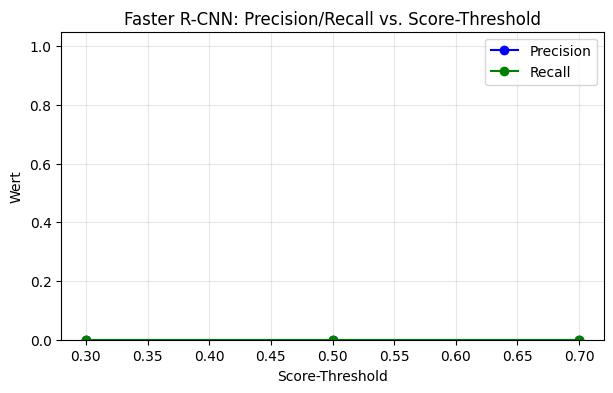

Thresholds: [0.3, 0.5, 0.7]
Precision: [0.0, 0.0, 0.0]
Recall: [0.0, 0.0, 0.0]

Berechne Plot 2 (Ground Truth vs. Modell)...


Sample-Vorhersagen:   0%|          | 0/4 [00:00<?, ?it/s]

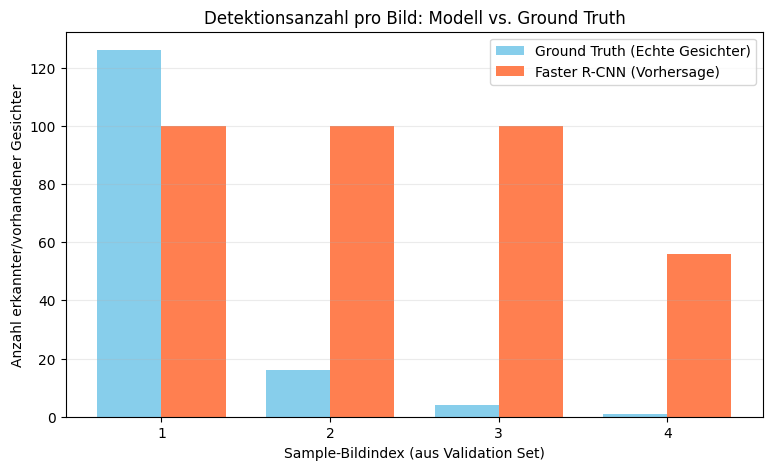

Mittelwert Ground Truth: 36.75
Mittelwert Faster R-CNN: 89.0


In [ ]:
import matplotlib.pyplot as plt
import os
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision.ops import box_iou
from tqdm.auto import tqdm

# ==========================================
# HILFSFUNKTION FÜR PLOT 1 (IoU Berechnung)
# ==========================================
def evaluate_detection_simple(model, data_loader, device, score_thresh=0.5, iou_thresh=0.5, desc="Evaluation"):
    model.eval()
    tp = fp = fn = 0
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=desc, leave=False):
            images = [img.to(device) for img in images]
            outputs = model(images)
            for output, target in zip(outputs, targets):
                gt_boxes = target["boxes"].to(device)
                pred_boxes = output["boxes"].to(device)
                scores = output["scores"].to(device)
                
                # Nur Vorhersagen über dem Schwellenwert behalten
                keep = scores >= score_thresh
                pred_boxes = pred_boxes[keep]
                
                if gt_boxes.numel() == 0 and pred_boxes.numel() == 0: continue
                if pred_boxes.numel() == 0:
                    fn += gt_boxes.shape[0]
                    continue
                if gt_boxes.numel() == 0:
                    fp += pred_boxes.shape[0]
                    continue
                    
                ious = box_iou(pred_boxes, gt_boxes)
                max_iou_pred, _ = ious.max(dim=1)
                tp += int((max_iou_pred >= iou_thresh).sum().item())
                fp += int((max_iou_pred < iou_thresh).sum().item())
                max_iou_gt, _ = ious.max(dim=0)
                fn += int((max_iou_gt < iou_thresh).sum().item())
                
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    return precision, recall

# ==========================================
# 1. DATEN VORBEREITEN
# ==========================================
# (Stelle sicher, dass die Variable 'path' vorher definiert wurde)
VAL_IMAGES_DIR = os.path.join(path, "WIDER_val/WIDER_val/images")
VAL_ANN_FILE = str(ANNOTATIONS_DIR / "instances_val.json")
TXT_VAL_PATH = os.path.join(path, "wider_face_split/wider_face_split/wider_face_val_bbx_gt.txt")
JSON_VAL_OUTPUT_PATH = VAL_ANN_FILE

# Konvertierung ausführen (Falls die JSON schon da ist, kann man das auskommentieren)
convert_wider_to_coco(TXT_VAL_PATH, JSON_VAL_OUTPUT_PATH)

# Val-Loader erstellen
full_val_dataset = CocoFaceDataset(VAL_IMAGES_DIR, VAL_ANN_FILE)
if REDUCTION_FACTOR > 1:
    # Wir nehmen hier den gleichen Faktor, um das Verhältnis 80/20 grob beizubehalten
    val_reduced_indices = list(range(0, len(full_val_dataset), REDUCTION_FACTOR))
    val_dataset = torch.utils.data.Subset(full_val_dataset, val_reduced_indices)
else:
    val_dataset = full_val_dataset
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print(f"📊 Setup bereit:")
print(f"   Bilder in der Validierung: {len(val_dataset)}")
try:
    print(f"   Bilder im Training: {len(train_dataset)}")
except NameError:
    pass # train_dataset ist in dieser Zelle nicht definiert, wird ignoriert

# ==========================================
# 2. MODELL LADEN
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Nutze Device für Qualitätsanalyse: {device}")

# Architektur laden
def build_faster_rcnn(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model
faster_det_model = build_faster_rcnn(num_classes=2)

# Gewichte laden
modell_pfad = str(MODEL_DIR / "fasterrcnn_resnet50_fpn_rocm_bs2_red2000_ep1.pth")
faster_det_model.load_state_dict(torch.load(modell_pfad, map_location=device, weights_only=True))
faster_det_model.to(device)
faster_det_model.eval() # GANZ WICHTIG!

# ==========================================
# 3. PLOTS ERSTELLEN
# ==========================================
# --- Plot 1: Precision/Recall ueber Score-Schwellen ---
if faster_det_model is not None and val_loader is not None:
    thresholds = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9]
    precisions = []
    recalls = []

    eval_device = device if device is not None else torch.device("cpu")
    print("Berechne Plot 1 (Precision/Recall)... Das kann einen Moment dauern.")
    
    for th in tqdm(thresholds, desc="Score-Thresholds"):
        p, r = evaluate_detection_simple(
            faster_det_model,
            val_loader,
            eval_device,
            score_thresh=th,
            iou_thresh=0.5,
            desc=f"IoU @ Score {th}",
        )
        precisions.append(float(p))
        recalls.append(float(r))

    plt.figure(figsize=(7, 4))
    plt.plot(thresholds, precisions, marker="o", label="Precision", color="blue")
    plt.plot(thresholds, recalls, marker="o", label="Recall", color="green")
    plt.title("Faster R-CNN: Precision/Recall vs. Score-Threshold")
    plt.xlabel("Score-Threshold")
    plt.ylabel("Wert")
    plt.ylim(0.0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    print("Thresholds:", thresholds)
    print("Precision:", [round(x, 4) for x in precisions])
    print("Recall:", [round(x, 4) for x in recalls])
else:
    print("Plot 1 uebersprungen: Modell oder Validation-Loader fehlt.")


# --- Plot 2: Vergleich der Detektionsanzahl pro Bild (Sample) mit der Ground Truth ---
if faster_det_model is not None and 'val_dataset' in globals():
    num_samples = min(10, len(val_dataset))
    
    frcnn_counts = []
    ground_truth_counts = []
    labels = []

    eval_device = device if device is not None else torch.device("cpu")
    faster_det_model.eval() 
    print("\nBerechne Plot 2 (Ground Truth vs. Modell)...")

    for i in tqdm(range(num_samples), desc="Sample-Vorhersagen"):
        image_tensor, target = val_dataset[i]
        
        # Ground Truth Boxen zählen
        gt_count = target["boxes"].shape[0]
        ground_truth_counts.append(gt_count)
        
        # Modell-Vorhersage
        img_input = [image_tensor.to(eval_device)]
        with torch.no_grad():
            output = faster_det_model(img_input)[0]
        
        score_thresh = 0.5 
        scores = output["scores"]
        pred_count = (scores >= score_thresh).sum().item()
        frcnn_counts.append(pred_count)
        
        labels.append(str(i + 1))

    if labels:
        x = np.arange(len(labels))
        width = 0.38

        plt.figure(figsize=(9, 5))
        plt.bar(x - width / 2, ground_truth_counts, width=width, label="Ground Truth (Echte Gesichter)", color="skyblue")
        plt.bar(x + width / 2, frcnn_counts, width=width, label="Faster R-CNN (Vorhersage)", color="coral")
        
        plt.title("Detektionsanzahl pro Bild: Modell vs. Ground Truth")
        plt.xlabel("Sample-Bildindex (aus Validation Set)")
        plt.ylabel("Anzahl erkannter/vorhandener Gesichter")
        plt.xticks(x, labels)
        plt.grid(axis="y", alpha=0.25)
        plt.legend()
        plt.show()

        print("Mittelwert Ground Truth:", round(float(np.mean(ground_truth_counts)), 2))
        print("Mittelwert Faster R-CNN:", round(float(np.mean(frcnn_counts)), 2))
    else:
        print("Plot 2 uebersprungen: Keine gueltigen Sample-Bilder gelesen.")
else:
    print("Plot 2 uebersprungen: Modell oder val_dataset fehlt.")

# Modelle vergleichen
### YOLOv8m-face vs. InsightFace vs. PyTorch-MTCNN vs. eigenes Faster R-CNN

##### Hinweis: Batching
Man könnte Modelle wie YOLO auch dazu zwingen, nicht 1 Bild, sondern direkt 10 Bilder auf einmal (als sogenannten Batch) in die Grafikkarte zu laden. Das würde die ms-Zahl von YOLO nochmal brutal nach unten drücken (weil Grafikkarten extrem gut im Parallelrechnen sind).
Da RetinaFace und MTCNN aber oft abstürzen, wenn man versucht ihnen Arrays mit variablen Bildgrößen zu übergeben, ist diese 1-zu-1-Schleife der fairste und stabilste Weg für unseren Benchmark!

Nutze Device für Modellvergleich: cuda
Lade Vergleichsmodelle in den Arbeitsspeicher...
YOLOv8 Modell geladen: /home/clemi/projekte/MIM/trained_models/yolov8m_widerface_rocm_bs2_red1_ep1.pt
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/clemi/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/clemi/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/clemi/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/clemi/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: [

Lade Testbilder:   0%|          | 0/3226 [00:00<?, ?it/s]

Daten geladen. Starte Modell-Benchmarks...

Teste YOLOv8...


YOLOv8:   0%|          | 0/4 [00:00<?, ?it/s]

Teste InsightFace...


...

Teste MTCNN...


MTCNN:   0%|          | 0/4 [00:00<?, ?it/s]

Teste Dein R-CNN...


Mein R-CNN:   0%|          | 0/4 [00:00<?, ?it/s]


--- FINALE ERGEBNISSE ---
Gesamtanzahl echter Gesichter: 12
YOLOv8       -> Recall: 8.33% | Zeit pro Bild: 10470.0 ms
InsightFace  -> Recall: 75.00% | Zeit pro Bild: 912.8 ms
MTCNN        -> Recall: 66.67% | Zeit pro Bild: 317.9 ms
Mein R-CNN   -> Recall: 33.33% | Zeit pro Bild: 3616.9 ms


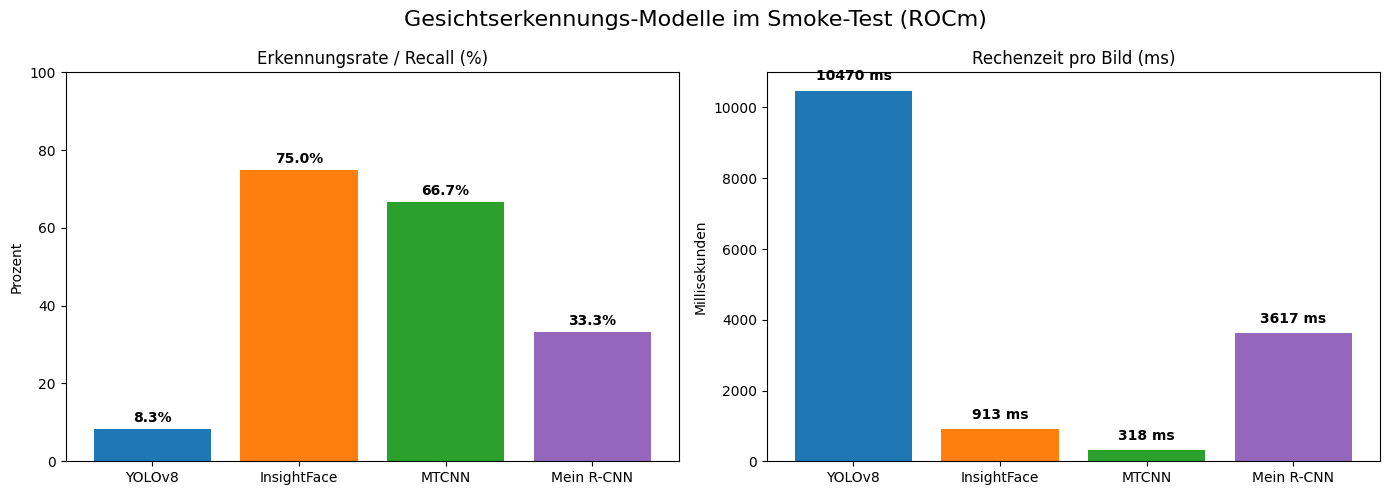

In [ ]:
import os
import cv2
import torch
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- NEU: Wichtige Imports für dein R-CNN ---
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from ultralytics import YOLO
from insightface.app import FaceAnalysis
from facenet_pytorch import MTCNN

# --- 1. Hilfsfunktionen ---
def compute_iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    if float(boxAArea + boxBArea - interArea) == 0: return 0
    return interArea / float(boxAArea + boxBArea - interArea)

def evaluate_boxes(true_faces, pred_boxes, threshold=0.4):
    detected = 0
    for true_face in true_faces:
        tx, ty, tw, th = true_face["bbox"]
        true_box = [tx, ty, tx + tw, ty + th]
        for pred_box in pred_boxes:
            if compute_iou(true_box, pred_box) > threshold:
                detected += 1
                break
    return detected

# --- DEINE EIGENE ARCHITEKTUR-FUNKTION ---
def build_faster_rcnn(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# --- 2. Vorbereitung & Umgebung ---
base_path = path if 'path' in locals() else "./"  
val_images_dir = os.path.join(base_path, "WIDER_val/WIDER_val/images")
val_gt_file = os.path.join(base_path, "wider_face_split/wider_face_split/wider_face_val_bbx_gt.txt")

# WICHTIG: Die Parse-Funktion muss geladen sein aus Absatz "Datensatz anschauen"
val_annotations = parse_wider_face_gt(val_gt_file)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
yolo_device = 0 if torch.cuda.is_available() else "cpu" 
print(f"Nutze Device für Modellvergleich: {device}")

# --- 3. Modelle laden ---
print("Lade Vergleichsmodelle in den Arbeitsspeicher...")
yolo_model_path = str(PROJECT_ROOT / "trained_models" / "yolov8m_widerface_rocm_bs2_red1_ep1.pt") if "PROJECT_ROOT" in globals() else "trained_models/yolov8m_widerface_rocm_bs2_red1_ep1.pt"
model_yolo = YOLO(yolo_model_path) if os.path.exists(yolo_model_path) else None
if model_yolo is None:
    print(f"YOLOv8 übersprungen: {yolo_model_path} ist lokal nicht vorhanden.")
else:
    print("YOLOv8 Modell geladen:", yolo_model_path)

app_insight = None
try:
    app_insight = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
    app_insight.prepare(ctx_id=-1, det_size=(1024, 1024))
except Exception as e:
    print(f"InsightFace wird übersprungen: {e}")

detector_mtcnn = None
try:
    detector_mtcnn = MTCNN(keep_all=True, device=torch.device("cpu"))
except Exception as e:
    print(f"MTCNN wird übersprungen: {e}") 

# -------------------------------------------------------------
# 4. EIGENES R-CNN MODELL LADEN
# -------------------------------------------------------------
rcnn_device = device # Kann je nach Hardware angepasst werden
mein_rcnn = build_faster_rcnn(num_classes=2)

try:
    mein_rcnn.load_state_dict(torch.load(str(MODEL_DIR / "fasterrcnn_resnet50_fpn_rocm_bs2_red2000_ep1.pth"), map_location=rcnn_device, weights_only=True))
    print("✅ Dein Custom R-CNN Modell wurde erfolgreich geladen!")
except Exception as e:
    print(f"❌ FEHLER beim Laden: {e}")

mein_rcnn.to(rcnn_device)
mein_rcnn.eval()
# -------------------------------------------------------------

# --- 4. DATEN PRE-LOADING ---
TEST_LIMIT = 100
IOU_THRESHOLD = 0.4

test_data = [] 
total_true_faces = 0

print(f"\nLade {TEST_LIMIT} ZUFÄLLIGE Bilder vorab in den RAM...")

# ---------------------------------------------------------
# Zufalls-Auswahl
alle_bilder = list(val_annotations.items())
random.seed(42) # Optional: Sorgt dafür, dass es bei jedem Start die gleichen zufälligen 50 Bilder sind (gut für Vergleiche)
random.shuffle(alle_bilder)
# ---------------------------------------------------------

# Wir iterieren jetzt über die gemischte Liste (alle_bilder) statt val_annotations.items()
for img_path, true_faces in tqdm(alle_bilder, desc="Lade Testbilder"):
    if len(test_data) >= TEST_LIMIT: break
    if len(true_faces) == 0: continue
        
    full_image_path = os.path.join(val_images_dir, img_path)
    img_bgr = cv2.imread(full_image_path)
    if img_bgr is None: continue
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    test_data.append({
        "bgr": img_bgr,
        "rgb": img_rgb,
        "true_faces": true_faces
    })
    total_true_faces += len(true_faces)

print("Daten geladen. Starte Modell-Benchmarks...\n")

metrics = {
    "YOLOv8": {"detected": 0, "time_sec": 0.0},
    "InsightFace": {"detected": 0, "time_sec": 0.0},
    "MTCNN": {"detected": 0, "time_sec": 0.0},
    "Mein R-CNN": {"detected": 0, "time_sec": 0.0}
}

# ==========================================
if model_yolo is None:
    print("Teste YOLOv8 übersprungen.")
else:
    print("Teste YOLOv8...")
    t0 = time.perf_counter()
    for data in tqdm(test_data, desc="YOLOv8"):
        res_yolo = model_yolo(data["bgr"], verbose=False, conf=0.25, imgsz=640, device=device)
        boxes_yolo = res_yolo[0].boxes.xyxy.cpu().numpy()
        if len(boxes_yolo) > 0:
            metrics["YOLOv8"]["detected"] += evaluate_boxes(data["true_faces"], boxes_yolo, IOU_THRESHOLD)
    metrics["YOLOv8"]["time_sec"] = time.perf_counter() - t0

    # ==========================================
print("Teste InsightFace...")
t0 = time.perf_counter()
if app_insight is not None:
    for data in tqdm(test_data, desc="InsightFace"):
        res_insight = app_insight.get(data["bgr"])
        boxes_insight = [face.bbox.astype(int) for face in res_insight]
        metrics["InsightFace"]["detected"] += evaluate_boxes(data["true_faces"], boxes_insight, IOU_THRESHOLD)
metrics["InsightFace"]["time_sec"] = time.perf_counter() - t0

# ==========================================
print("Teste MTCNN...")
t0 = time.perf_counter()
if detector_mtcnn is not None:
    for data in tqdm(test_data, desc="MTCNN"):
        boxes_mtcnn, probs = detector_mtcnn.detect(data["rgb"])
        if boxes_mtcnn is not None:
            metrics["MTCNN"]["detected"] += evaluate_boxes(data["true_faces"], boxes_mtcnn, IOU_THRESHOLD)
metrics["MTCNN"]["time_sec"] = time.perf_counter() - t0

# ==========================================
print("Teste Dein R-CNN...")
t0 = time.perf_counter()
tensor_transform = T.ToTensor()

for data in tqdm(test_data, desc="Mein R-CNN"):
    img_tensor = tensor_transform(data["rgb"]).to(rcnn_device)
    
    with torch.no_grad():
        prediction = mein_rcnn([img_tensor])[0]
    
    boxes_rcnn = prediction["boxes"].cpu().numpy()
    scores_rcnn = prediction["scores"].cpu().numpy()
    
    valid_boxes = boxes_rcnn[scores_rcnn > 0.25]
    
    if len(valid_boxes) > 0:
        metrics["Mein R-CNN"]["detected"] += evaluate_boxes(data["true_faces"], valid_boxes, IOU_THRESHOLD)
        
metrics["Mein R-CNN"]["time_sec"] = time.perf_counter() - t0

# --- 5. Daten für das Diagramm aufbereiten ---
model_names = list(metrics.keys())
recalls = []
times_per_image = []

print("\n--- FINALE ERGEBNISSE ---")
print(f"Gesamtanzahl echter Gesichter: {total_true_faces}")

for name in model_names:
    recall = (metrics[name]["detected"] / total_true_faces) * 100 if total_true_faces > 0 else 0
    recalls.append(recall)
    time_ms = (metrics[name]["time_sec"] / len(test_data)) * 1000
    times_per_image.append(time_ms)
    print(f"{name:12} -> Recall: {recall:.2f}% | Zeit pro Bild: {time_ms:.1f} ms")

# --- 6. Diagramm zeichnen (4 Modelle) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gesichtserkennungs-Modelle im Smoke-Test (ROCm)', fontsize=16)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

bars1 = ax1.bar(model_names, recalls, color=colors)
ax1.set_title('Erkennungsrate / Recall (%)')
ax1.set_ylabel('Prozent')
ax1.set_ylim(0, 100)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold')

bars2 = ax2.bar(model_names, times_per_image, color=colors)
ax2.set_title('Rechenzeit pro Bild (ms)')
ax2.set_ylabel('Millisekunden')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(times_per_image)*0.02), 
             f'{bar.get_height():.0f} ms', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Praktisches Face Blurring nach dem Modellvergleich

**Milena Witt** konzentrierte sich primär auf Aufgaben zur Vorverarbeitung von Videos und auf notwendige Schritte zur Umsetzung eines möglichst praxistauglichen Face Blurring. 

Für die eigentliche Gesichtserkennung/Zensur ist YOLOv8-Face der pragmatischste erste Schritt: Es ist schnell, robust im Videostream und lässt sich direkt mit Tracking (`model.track`) kombinieren. Das selbst trainierte Faster R-CNN bleibt als Qualitäts-/Fallback-Modell nützlich, ist aber für Frame-für-Frame-Videoverarbeitung deutlich schwerer. Die empfohlene Pipeline ist daher: Video kurz normalisieren/deinterlacen, YOLOv8-Face auf jedem n-ten Frame ausführen, Boxen per Tracker weiterführen und anschließend die erkannten Gesichter mit der ovalen Blur-Maske zensieren.


# De-Interlacing + Gesichtserkennung

In [ ]:
import os
import re
import cv2
import time
import subprocess
import numpy as np
from pathlib import Path
from ultralytics import YOLO
from tqdm.auto import tqdm

# ==========================================
# 1. KONFIGURATION (Hier anpassen!)
# ==========================================
if "PROJECT_ROOT" not in globals():
    current_path = Path.cwd().resolve()
    PROJECT_ROOT = next(
        (candidate for candidate in [current_path, *current_path.parents] if (candidate / "Videos" / "Milenas").exists()),
        current_path,
    )

video_ordner = PROJECT_ROOT / "Videos" / "Milenas" # entsprechend anpassen
dateiname = "Feuerwehr.mp4" # ausgwähltes Video

original_video = str(video_ordner / dateiname)

# Generiert automatisch die Dateinamen für Ausgaben
name_ohne_endung, endung = os.path.splitext(original_video)
deinterlaced_video = f"{name_ohne_endung}_progressiv{endung}"
final_output_video = f"{name_ohne_endung}_zensiert_smoketest.mp4"

model_path = str(PROJECT_ROOT / "trained_models" / "yolov8m_widerface_rocm_bs2_red1_ep1.pt")

# Parameter
BACKGROUND_THRESHOLD_PERCENT = 0.02  # Zensiere Gesichter, die kleiner als x% des Bildes sind
CONFIDENCE_THRESHOLD = 0.45          # Sicherheit des Modells
FRAME_SKIP = 2                       # Smoke-Test: Analyse nur jeden 2. Frame
MAX_TEST_FRAMES = 30                  # Smoke-Test: nur die ersten Frames rendern
BLUR_STRENGTH = (71, 71)             # Stärke des Weichzeichners (muss ungerade sein!)

# ==========================================
# 2. HILFSFUNKTIONEN (FFMPEG)
# ==========================================
def check_if_interlaced(video_path, num_frames_to_test=30, skip_seconds=0):
    """
    Scannt eine Stichprobe im Video Frame-genau und berücksichtigt unbestimmte Frames.
    """
    print(f"🔍 Analysiere Video ab Sekunde {skip_seconds} für {num_frames_to_test} Frames...")
    
    cmd = [
        'ffmpeg', 
        '-i', video_path, 
        '-ss', str(skip_seconds), # WICHTIG: Jetzt NACH dem Input für 100% Präzision!
        '-filter_complex', 'idet', 
        '-frames:v', str(num_frames_to_test), 
        '-f', 'null', '-'
    ]
    
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    
    # Der Regex sucht nun nach allen 4 Werten (inklusive Undetermined)
    match = re.search(r'Multi frame detection:\s+TFF:\s*(\d+)\s+BFF:\s*(\d+)\s+Progressive:\s*(\d+)\s+Undetermined:\s*(\d+)', result.stderr)
    
    if match:
        tff = int(match.group(1))
        bff = int(match.group(2))
        progressive = int(match.group(3))
        undetermined = int(match.group(4))
        
        total_interlaced = tff + bff
        total_scanned = total_interlaced + progressive + undetermined
        
        print(f"  -> Treffer: Interlaced: {total_interlaced}, Progressiv: {progressive}, Unbestimmt: {undetermined}")
        
        # Sicherheits-Check 1: FFmpeg hat sich verschluckt
        if total_scanned == 0:
            print("  -> ⚠️ WARNUNG: Keine Frames gelesen. Container fehlerhaft. Sicherheitshalber Deinterlacen!")
            return True
            
        # Sicherheits-Check 2: Das Bild ist extrem statisch/unscharf
        if undetermined > (total_scanned * 0.8):
            print("  -> ⚠️ WARNUNG: Zu viele unbestimmte Frames. Bild ist zu statisch für Analyse. Gehe auf Nummer sicher!")
            return True # Lieber Deinterlacen als abstürzen lassen
        
        # Die eigentliche Logik: Sind genügend Halbbilder da?
        if total_interlaced > (progressive * 0.1): 
            return True
            
    else:
        print("  -> ⚠️ WARNUNG: FFmpeg Ausgabe konnte nicht gelesen werden.")
        return True # Fallback
        
    return False

def run_ffmpeg_deinterlace(input_path, output_path):
    print("🎬 Starte FFmpeg Deinterlacing (Yadif)... Bitte warten...")
    cmd = ['ffmpeg', '-y', '-i', input_path, '-vf', 'yadif=1', '-c:v', 'libx264', '-preset', 'fast', '-crf', '18', '-c:a', 'copy', output_path]
    subprocess.run(cmd, check=True)
    print(f"✅ Deinterlacing erfolgreich! Gespeichert als: {output_path}\n")

# ==========================================
# 3. PRE-PROCESSING (Der Bitstream-Wash)
# ==========================================
if not os.path.exists(original_video):
    raise FileNotFoundError(f"FEHLER: Das Video '{original_video}' wurde nicht gefunden!")

SMOKE_TEST_VIDEO = True

if SMOKE_TEST_VIDEO:
    if os.path.exists(deinterlaced_video):
        print("ℹ️ Smoke-Test aktiv: nutze vorhandene Progressiv-Version und überspringe vollständigen FFmpeg-Wash.")
        video_path_for_yolo = deinterlaced_video
    else:
        print("ℹ️ Smoke-Test aktiv: nutze Originalvideo direkt und überspringe vollständigen FFmpeg-Wash.")
        video_path_for_yolo = original_video
elif check_if_interlaced(original_video):
    print("⚠️ Echte Halbbilder erkannt! Starte aufwendiges Deinterlacing (Yadif)...")
    if not os.path.exists(deinterlaced_video):
        run_ffmpeg_deinterlace(original_video, deinterlaced_video)
    else:
         print("ℹ️ Progressiv-Version existiert bereits.")
    video_path_for_yolo = deinterlaced_video

else:
    print("✅ Bildmaterial ist progressiv! Starte blitzschnellen Bitstream-Wash...")
    fast_clean_video = f"{name_ohne_endung}_fastclean{endung}"
    
    if not os.path.exists(fast_clean_video):
        cmd_wash = [
            'ffmpeg', '-y', '-i', original_video, 
            '-c', 'copy', 
            '-bsf:v', 'h264_metadata=interlaced=0',
            fast_clean_video
        ]
        
        result = subprocess.run(cmd_wash, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        
        if result.returncode != 0:
            print("⚠️ Bitstream-Filter inkompatibel. Nutze Ultraschnell-Encoder für den Wash...")
            cmd_fallback = [
                'ffmpeg', '-y', '-i', original_video, 
                '-c:v', 'libx264', '-preset', 'ultrafast', '-crf', '18', 
                '-c:a', 'copy', fast_clean_video
            ]
            subprocess.run(cmd_fallback, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        else:
            print("⚡ Bitstream erfolgreich gewaschen!")
    else:
        print("ℹ️ Gewaschene Version existiert bereits.")
        
    video_path_for_yolo = fast_clean_video

# ==========================================
# 4. YOLO SETUP & VIDEO-STREAM ÖFFNEN
# ==========================================
print("\n🤖 Lade YOLOv8m-Face Modell...")
if not os.path.exists(model_path):
    print(f"Überspringe Video-Smoke-Test: {model_path} ist lokal nicht vorhanden.")
else:
    model = YOLO(model_path)

    cap = cv2.VideoCapture(video_path_for_yolo)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    img_area = width * height

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(final_output_video, fourcc, fps, (width, height))

    print(f"\n🚀 STARTE VIDEOVERARBEITUNG")
    frames_to_process = min(MAX_TEST_FRAMES, total_frames) if MAX_TEST_FRAMES else total_frames
    print(f"   Auflösung: {width}x{height} | Frames im Test: {frames_to_process}/{total_frames} | FPS: {fps}")

    start_time = time.perf_counter()
    frame_count = 0
    cached_boxes = []

    # ==========================================
    # 5. DIE HAUPTSCHLEIFE
    # ==========================================
    progress = tqdm(total=frames_to_process, desc="Video-Smoke-Test")
    while cap.isOpened() and frame_count < frames_to_process:
        ret, frame = cap.read()
        if not ret:
            break

        # KI Analyse nur bei jedem X-ten Frame (spart massiv CPU/GPU Zeit)
        if frame_count % FRAME_SKIP == 0:
            # Tracking-Modus mit GPU (MPS) und 16:9 Rechteck-Optimierung
            results = model.track(
                frame, 
                persist=True, 
                tracker="bytetrack.yaml", 
                verbose=False, 
                conf=CONFIDENCE_THRESHOLD, 
                imgsz=(1088, 1920),
                device=(0 if hasattr(__import__('torch'), 'cuda') and __import__('torch').cuda.is_available() else 'cpu')
            )
        
            # Falls Boxen gefunden wurden, speichere sie ab (ansonsten leere Liste)
            if results[0].boxes:
                cached_boxes = results[0].boxes.xyxy.cpu().numpy()
            else:
                cached_boxes = []

        # Zensur-Logik anwenden
        for box in cached_boxes:
            x1, y1, x2, y2 = map(int, box)
        
            # 1. Breite und Höhe des erkannten Gesichts
            face_w = x2 - x1
            face_h = y2 - y1
        
            # 2. Hintergrund-Check (< 1%) VOR der Vergrößerung berechnen!
            face_area = face_w * face_h
            face_percentage = face_area / img_area
        
            if face_percentage < BACKGROUND_THRESHOLD_PERCENT:
            
                # 3. PADDING (Erweiterung) berechnen
                # Faktor 0.5 bedeutet: Wir fügen 50% der Gesichtsbreite/-höhe auf ALLEN Seiten hinzu
                PADDING_FACTOR = 0.5 
                pad_x = int(face_w * PADDING_FACTOR)
                pad_y = int(face_h * PADDING_FACTOR)
            
                # 4. Neue, viel größere Koordinaten berechnen (und gegen den Bildrand absichern)
                ex1 = max(0, x1 - pad_x)
                ey1 = max(0, y1 - pad_y)
                ex2 = min(width, x2 + pad_x)
                ey2 = min(height, y2 + pad_y)
            
                # 5. Den vergrößerten Bereich (ROI) aus dem Frame ausschneiden
                roi = frame[ey1:ey2, ex1:ex2]
            
                if roi.size > 0: 
                    # Den gesamten riesigen Ausschnitt weichzeichnen
                    blurred_roi = cv2.GaussianBlur(roi, (99, 99), 0) 
                
                    # Leere Maske in der neuen, großen Größe erstellen
                    mask = np.zeros_like(roi, dtype=np.uint8)
                
                    # 6. WO IST DAS GESICHT JETZT?
                    # Wir brauchen den Mittelpunkt des Gesichts relativ zu unserem neuen, großen Ausschnitt
                    center_x_frame = x1 + (face_w // 2)
                    center_y_frame = y1 + (face_h // 2)
                
                    # Mittelpunkt im ROI:
                    center_x_roi = center_x_frame - ex1
                    center_y_roi = center_y_frame - ey1
                    center = (center_x_roi, center_y_roi)
                
                    # 7. Größe des Ovals definieren (Halbe Breite/Höhe des eigentlichen Gesichts)
                    # Du kannst den Faktor (hier 1.8) leicht erhöhen, wenn das Oval das Gesicht großzügiger abdecken soll
                    # 1. Wir ignorieren "Geister-Gesichter", deren Breite/Höhe negativ oder 0 ist
                    if face_w <= 0 or face_h <= 0:
                        continue 

                    # 2. Wir berechnen die Achsen und zwingen sie mit max(), immer mindestens 1 Pixel groß zu sein!
                    axis_x = max(1, int((face_w / 2) * 1.8))
                    axis_y = max(1, int((face_h / 2) * 1.8))
                    axes = (axis_x, axis_y)
                
                    # Das weiße Oval zeichnen
                    cv2.ellipse(mask, center, axes, 0, 0, 360, (255, 255, 255), -1)
                
                    # 8. Maske extrem weichzeichnen (jetzt hat sie genug Platz zum Ausfaden!)
                    mask = cv2.GaussianBlur(mask, (71, 71), 0)
                
                    # 9. Alpha-Blending
                    mask_float = mask.astype(float) / 255.0
                    roi_float = roi.astype(float)
                    blurred_roi_float = blurred_roi.astype(float)
                
                    blended_roi = (blurred_roi_float * mask_float) + (roi_float * (1.0 - mask_float))
                
                    # 10. Den großen Ausschnitt wieder exakt an die richtige Stelle im Originalbild kleben
                    frame[ey1:ey2, ex1:ex2] = blended_roi.astype(np.uint8)

        # Frame speichern und zählen
        out.write(frame)
        frame_count += 1
        progress.update(1)

    # ==========================================
    # 6. AUFRÄUMEN & PERFORMANCE REPORT
    # ==========================================
    progress.close()
    cap.release()
    out.release()

    end_time = time.perf_counter()
    total_time = end_time - start_time
    minutes = int(total_time // 60)
    seconds = total_time % 60

    processing_fps = frame_count / total_time
    video_duration_seconds = frame_count / fps if fps else 0
    realtime_factor = video_duration_seconds / total_time

    print("\n" + "="*50)
    print("             ZENSUR-REPORT            ")
    print("="*50)
    print(f"🎬 Fertiges Video:    {final_output_video}")
    print(f"⏱️  Benötigte Zeit:    {minutes} Min. und {seconds:.2f} Sek.")
    print(f"⚡  Renderspeed:       {processing_fps:.2f} FPS")
    print(f"🚀  Echtzeit-Faktor:   {realtime_factor:.2f}x")

    if realtime_factor > 1:
        print(f"\n--> 🏆 SUPER! Dein Mac ist {realtime_factor:.1f}-mal schneller als Echtzeit.")
    else:
        print(f"\n--> ℹ️ Das Rendern dauerte {1/realtime_factor:.1f}-mal länger als das Video.")
    print("="*50)


ℹ️ Smoke-Test aktiv: nutze vorhandene Progressiv-Version und überspringe vollständigen FFmpeg-Wash.

🤖 Lade YOLOv8m-Face Modell...

🚀 STARTE VIDEOVERARBEITUNG
   Auflösung: 1920x1080 | Frames im Test: 30/1306 | FPS: 50.019149751053234


Video-Smoke-Test:   0%|          | 0/30 [00:00<?, ?it/s]


             ZENSUR-REPORT            
🎬 Fertiges Video:    /home/clemi/projekte/MIM/Videos/Milenas/Feuerwehr_zensiert_smoketest.mp4
⏱️  Benötigte Zeit:    0 Min. und 9.44 Sek.
⚡  Renderspeed:       3.18 FPS
🚀  Echtzeit-Faktor:   0.06x

--> ℹ️ Das Rendern dauerte 15.7-mal länger als das Video.


# Tracker-Optimierung

Durch die vielen Frames eines Videos, haben die Modelle noch Probleme Gesichter zuverlässig durchgängig zu erkennen und es kommt zu "Flickering". Außerdem verschwinden die Masken über Gesichtern, wenn die Person der Kamera den Rücken zuwendet. Dafür wurden noch Smoothing-Parameter eingeführt. Die genaue Auswirkung lässt sich nur optisch durch den Menschen vergleichen.

In [ ]:
import os
import re
import cv2
import time
import subprocess
import numpy as np
from ultralytics import YOLO

# ==========================================
# 1. KONFIGURATION (Hier anpassen!)
# ==========================================
video_ordner = "Videos"
dateiname = "Demo_Marktplatz.mp4" # <--- Dein Video

original_video = os.path.join(video_ordner, dateiname)

# Generiert automatisch die Dateinamen für Ausgaben
name_ohne_endung, endung = os.path.splitext(original_video)
deinterlaced_video = f"{name_ohne_endung}_progressiv{endung}"
final_output_video = f"{name_ohne_endung}_zensiert_getrackt.mp4"

model_path = "face_yolov8m.pt"   # Dein gewähltes Modell

# Parameter
BACKGROUND_THRESHOLD_PERCENT = 0.02  # Zensiere Gesichter, die kleiner als x% des Bildes sind
CONFIDENCE_THRESHOLD = 0.45          # Sicherheit des Modells
FRAME_SKIP = 1                       # Nur jeden 3. Frame neu analysieren (Rest wird getrackt/gecached)
BLUR_STRENGTH = (71, 71)             # Stärke des Weichzeichners (muss ungerade sein!)

# ==========================================
# 2. HILFSFUNKTIONEN (FFMPEG)
# ==========================================
def check_if_interlaced(video_path, num_frames_to_test=300, skip_seconds=10):
    """
    Scannt eine Stichprobe im Video Frame-genau und berücksichtigt unbestimmte Frames.
    """
    print(f"🔍 Analysiere Video ab Sekunde {skip_seconds} für {num_frames_to_test} Frames...")
    
    cmd = [
        'ffmpeg', 
        '-i', video_path, 
        '-ss', str(skip_seconds), # WICHTIG: Jetzt NACH dem Input für 100% Präzision!
        '-filter_complex', 'idet', 
        '-frames:v', str(num_frames_to_test), 
        '-f', 'null', '-'
    ]
    
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    
    # Der Regex sucht nun nach allen 4 Werten (inklusive Undetermined)
    match = re.search(r'Multi frame detection:\s+TFF:\s*(\d+)\s+BFF:\s*(\d+)\s+Progressive:\s*(\d+)\s+Undetermined:\s*(\d+)', result.stderr)
    
    if match:
        tff = int(match.group(1))
        bff = int(match.group(2))
        progressive = int(match.group(3))
        undetermined = int(match.group(4))
        
        total_interlaced = tff + bff
        total_scanned = total_interlaced + progressive + undetermined
        
        print(f"  -> Treffer: Interlaced: {total_interlaced}, Progressiv: {progressive}, Unbestimmt: {undetermined}")
        
        # Sicherheits-Check 1: FFmpeg hat sich verschluckt
        if total_scanned == 0:
            print("  -> ⚠️ WARNUNG: Keine Frames gelesen. Container fehlerhaft. Sicherheitshalber Deinterlacen!")
            return True
            
        # Sicherheits-Check 2: Das Bild ist extrem statisch/unscharf
        if undetermined > (total_scanned * 0.8):
            print("  -> ⚠️ WARNUNG: Zu viele unbestimmte Frames. Bild ist zu statisch für Analyse. Gehe auf Nummer sicher!")
            return True # Lieber Deinterlacen als abstürzen lassen
        
        # Die eigentliche Logik: Sind genügend Halbbilder da?
        if total_interlaced > (progressive * 0.1): 
            return True
            
    else:
        print("  -> ⚠️ WARNUNG: FFmpeg Ausgabe konnte nicht gelesen werden.")
        return True # Fallback
        
    return False

def run_ffmpeg_deinterlace(input_path, output_path):
    print("🎬 Starte FFmpeg Deinterlacing (Yadif)... Bitte warten...")
    cmd = ['ffmpeg', '-y', '-i', input_path, '-vf', 'yadif=1', '-c:v', 'libx264', '-preset', 'fast', '-crf', '18', '-c:a', 'copy', output_path]
    subprocess.run(cmd, check=True)
    print(f"✅ Deinterlacing erfolgreich! Gespeichert als: {output_path}\n")

# ==========================================
# 3. PRE-PROCESSING (Der Bitstream-Wash)
# ==========================================
if not os.path.exists(original_video):
    raise FileNotFoundError(f"FEHLER: Das Video '{original_video}' wurde nicht gefunden!")

if check_if_interlaced(original_video):
    print("⚠️ Echte Halbbilder erkannt! Starte aufwendiges Deinterlacing (Yadif)...")
    if not os.path.exists(deinterlaced_video):
        run_ffmpeg_deinterlace(original_video, deinterlaced_video)
    else:
         print("ℹ️ Progressiv-Version existiert bereits.")
    video_path_for_yolo = deinterlaced_video

else:
    print("✅ Bildmaterial ist progressiv! Starte blitzschnellen Bitstream-Wash...")
    fast_clean_video = f"{name_ohne_endung}_fastclean{endung}"
    
    if not os.path.exists(fast_clean_video):
        # VERSUCH 1: Der Bitstream-Filter (löscht den Interlaced-Stempel direkt im Codec, dauert ca. 1-2 Sekunden)
        cmd_wash = [
            'ffmpeg', '-y', '-i', original_video, 
            '-c', 'copy', 
            '-bsf:v', 'h264_metadata=interlaced=0',  # <--- HIER IST DIE MAGIE
            fast_clean_video
        ]
        
        result = subprocess.run(cmd_wash, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        
        # Falls das Video kein normales H.264 ist, schlägt der Filter fehl. 
        # VERSUCH 2: Ultraschneller Re-Encode als Sicherheitsnetz (dauert etwas länger, ist aber zu 100% sicher)
        if result.returncode != 0:
            print("⚠️ Bitstream-Filter inkompatibel. Nutze Ultraschnell-Encoder für den Wash...")
            cmd_fallback = [
                'ffmpeg', '-y', '-i', original_video, 
                '-c:v', 'libx264', '-preset', 'ultrafast', '-crf', '18', 
                '-c:a', 'copy', fast_clean_video
            ]
            subprocess.run(cmd_fallback, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        else:
            print("⚡ Bitstream erfolgreich gewaschen!")
    else:
        print("ℹ️ Gewaschene Version existiert bereits.")
        
    video_path_for_yolo = fast_clean_video

# ==========================================
# 4. YOLO SETUP & VIDEO-STREAM ÖFFNEN
# ==========================================
print("\n🤖 Lade YOLOv8m-Face Modell...")
model = YOLO("face_yolov8m.pt") # Zurück zum verlässlichen Face-Modell!

cap = cv2.VideoCapture(video_path_for_yolo)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
img_area = width * height

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(final_output_video, fourcc, fps, (width, height))

# --- NEUE TV-PRODUKTIONS PARAMETER ---
MAX_LOST_FRAMES = int(fps * 1.5)  # Wie lange bleibt die Maske, wenn sich jemand wegdreht? (Hier: 1.5 Sekunden)
SMOOTHING = 0.6                   # 1.0 = Box springt sofort (flackert). 0.1 = Box ist extrem träge.

# Memory-Buffer für unsere Gesichter
track_history = {} # Format: { track_id: {"box": [x1,y1,x2,y2], "lost_count": 0} }

print(f"\n🚀 STARTE VIDEOVERARBEITUNG (Mit Ghost-Tracking)")
start_time = time.perf_counter()
frame_count = 0

# ==========================================
# 5. DIE HAUPTSCHLEIFE
# ==========================================
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    # Tracking bei jedem Frame (wichtig für flüssige Bewegungen im TV)
    results = model.track(
        frame, 
        persist=True, 
        tracker="bytetrack.yaml", 
        verbose=False, 
        conf=CONFIDENCE_THRESHOLD, 
        device='mps' # oder 'cpu'
    )
    
    current_ids = []

    # 1. AKTUELLE GESICHTER EINLESEN UND GLÄTTEN
    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)

        for box, track_id in zip(boxes, ids):
            current_ids.append(track_id)
            
            if track_id in track_history:
                # GESICHT BEKANNT: Wir glätten die Bewegung (tötet das Flackern!)
                old_box = track_history[track_id]["box"]
                new_box = old_box * (1 - SMOOTHING) + box * SMOOTHING
                track_history[track_id]["box"] = new_box
                track_history[track_id]["lost_count"] = 0 # Countdown resetten
            else:
                # NEUES GESICHT: Sofort übernehmen
                track_history[track_id] = {"box": box, "lost_count": 0}

    # 2. GHOST-TRACKING FÜR VERLORENE GESICHTER (Hinterkopf-Problem)
    for track_id in list(track_history.keys()):
        if track_id not in current_ids:
            track_history[track_id]["lost_count"] += 1
            # Wenn das Gesicht zu lange weg ist (z.B. Person ist aus dem Bild gelaufen), löschen!
            if track_history[track_id]["lost_count"] > MAX_LOST_FRAMES:
                del track_history[track_id]

    # 3. ZENSUR FÜR ALLE GESICHTER (Aktive UND Ghosts) ZEICHNEN
    for track_id, data in track_history.items():
        box = data["box"]
        x1, y1, x2, y2 = map(int, box)
        
        face_w = x2 - x1
        face_h = y2 - y1
        if face_w <= 0 or face_h <= 0: continue
        
        # Hintergrund-Check
        face_percentage = (face_w * face_h) / img_area
        if face_percentage < BACKGROUND_THRESHOLD_PERCENT:
            
            # --- DEIN BEWÄHRTES OVAL-PADDING ---
            PADDING_FACTOR = 0.4 
            pad_x = int(face_w * PADDING_FACTOR)
            pad_y = int(face_h * PADDING_FACTOR)
            
            ex1 = max(0, x1 - pad_x)
            ey1 = max(0, y1 - pad_y)
            ex2 = min(width, x2 + pad_x)
            ey2 = min(height, y2 + pad_y)
            
            roi = frame[ey1:ey2, ex1:ex2]
            
            if roi.size > 0: 
                blurred_roi = cv2.GaussianBlur(roi, (99, 99), 0) 
                mask = np.zeros_like(roi, dtype=np.uint8)
                
                center_x_frame = x1 + (face_w // 2)
                center_y_frame = y1 + (face_h // 2)
                center = (center_x_frame - ex1, center_y_frame - ey1)
                
                axis_x = max(1, int((face_w / 2) * 1.8))
                axis_y = max(1, int((face_h / 2) * 1.8))
                
                cv2.ellipse(mask, center, (axis_x, axis_y), 0, 0, 360, (255, 255, 255), -1)
                mask = cv2.GaussianBlur(mask, (71, 71), 0)
                
                mask_float = mask.astype(float) / 255.0
                roi_float = roi.astype(float)
                blurred_roi_float = blurred_roi.astype(float)
                
                blended_roi = (blurred_roi_float * mask_float) + (roi_float * (1.0 - mask_float))
                frame[ey1:ey2, ex1:ex2] = blended_roi.astype(np.uint8)

    out.write(frame)
    frame_count += 1
    
    if frame_count % 200 == 0:
        print(f"   Bearbeitet: {frame_count}/{total_frames} Frames")

# ==========================================
# 6. AUFRÄUMEN & PERFORMANCE REPORT
# ==========================================
cap.release()
out.release()

end_time = time.perf_counter()
total_time = end_time - start_time
minutes = int(total_time // 60)
seconds = total_time % 60

processing_fps = frame_count / total_time
video_duration_seconds = total_frames / fps
realtime_factor = video_duration_seconds / total_time

print("\n" + "="*50)
print("             ZENSUR-REPORT            ")
print("="*50)
print(f"🎬 Fertiges Video:    {final_output_video}")
print(f"⏱️  Benötigte Zeit:    {minutes} Min. und {seconds:.2f} Sek.")
print(f"⚡  Renderspeed:       {processing_fps:.2f} FPS")
print(f"🚀  Echtzeit-Faktor:   {realtime_factor:.2f}x")

if realtime_factor > 1:
    print(f"\n--> 🏆 SUPER! Dein Mac ist {realtime_factor:.1f}-mal schneller als Echtzeit.")
else:
    print(f"\n--> ℹ️ Das Rendern dauerte {1/realtime_factor:.1f}-mal länger als das Video.")
print("="*50)

Kurzwerte aus dem Vergleich:
YOLOv8 Recall: 8.33%, 137.4 ms/Bild
InsightFace Recall: 75.00%
MTCNN Recall: 66.67%
Mein R-CNN Recall: 33.33%